### Studio 13: Our First CNN

Original Author: Andrew Connolly, University of Washington Thanks to Hayden Smotherman, University of Washington for the example networks.

This notebook is based on work by Javier Duarte for UCSD PHYS 139/239: Machine Learning in Physics (2023), https://jduarte.physics.ucsd.edu/phys139_239

Modifications by Julieta Gruszko (2025).

In this notebook we work through a simple example for a neural network and CNN using Keras. Initially we will start with a fully connected neural network, and then study a simple a convolutional neural network. Then we'll see how we can start to understand what the network is doing. 

The data we are using is taken from a survey for NEOs by Lori Allen and collaborators using DECam on the Blanco 4m Telescope at CTIO. The data comprise a stack of images taken over a period of 5 nights. Within these images we search for slowly moving sources (TNOs) along potential orbital trajectories. Given these trajectories we coadd the images. Our goal is to determine whether there is a point source within the coadded images. The training sample includes images of simulated TNOs (true positives; stamps_sources.npz) and random trajectories where there is no known source (false positives; stamps_noise.npz). The true positives range in signal-to-noise from 100 to 3.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler

import matplotlib
import matplotlib.pyplot as plt

import torch as torch
import torch.nn as nn

In [2]:
import os
os.environ["KERAS_BACKEND"] = "torch"

Here are some helper functions we'll use for plotting:

In [3]:
np.set_printoptions(precision=2)

def normalize_image(image):
    '''Rescale the constrast in an image based on the noise (used for displays and the CNN)'''
    sigmaG_coeff =  0.7413
    image = image.reshape(21,21)
    
    per25,per50,per75 = np.percentile(image,[25,50,75])
    sigmaG = sigmaG_coeff * (per75 - per25)
    # sigma clip image, remove background, and normalize to unity
    image[image<(per50-2*sigmaG)] = per50-2*sigmaG
    image -= np.min(image)
    image /= np.sum(image)
    
    return image
    
def plot_image_array(images, nrows=2, ncols=5, figsize=[8,4], nx=21, ny=21, title='', subtitle=False, 
                     class_true=None, classes=None):
    '''Plot an array of images'''
    fig, ax = plt.subplots(nrows=nrows,ncols=ncols,figsize=figsize)
    fig.subplots_adjust(hspace=.3, left=0.07, right=0.95, wspace=0.1, bottom=0.15)
    for indx in np.arange(nrows*ncols):
        i = int(indx/ncols)
        j = indx%ncols
        if (i == 0):
            ax[i][j].xaxis.set_major_formatter(plt.NullFormatter())
        if (j != 0):
            ax[i][j].yaxis.set_major_formatter(plt.NullFormatter())

        ax[i][j].imshow(images[indx].reshape(nx,ny), cmap='gray')
        if (subtitle == True):
            ax[i][j].set_title('True Class: %d, Pred Class: %d\n  Prob Class 1 %.1f ' % 
              (np.argmax(class_true[indx]), np.argmax(classes[indx]), classes[indx,1]), color='blue', fontsize=6)

    fig.suptitle(title)
    ax[0][0].set_ylabel('$y$')
    ax[nrows-1][int(ncols/2)].set_xlabel('$x$')            
    
from sklearn.metrics import confusion_matrix
from sklearn.utils.multiclass import unique_labels

def plot_confusion_matrix(y_true, y_pred, 
                          normalize=False,
                          title=None,
                          cmap=plt.cm.Blues, 
                          ylabel = 'True label', 
                          xlabel = 'Predicted label'):
    """
    From scikit-learn: plots a confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if not title:
        if normalize:
            title = 'Normalized confusion matrix'
        else:
            title = 'Confusion matrix, without normalization'

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)

    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           # ... and label them with the respective list entries
           title=title,
           ylabel=ylabel,
           xlabel=xlabel)

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    #fixes "squishing of plot"
    plt.ylim([1.5, -.5]) 
    
    # Loop over data dimensions and create text annotations.
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()

def plot_model_history(history, n_epochs):
    '''Plot the training and validation history for a TensorFlow network'''

    # Extract loss and accuracy
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    
    fig, ax = plt.subplots(nrows=1,ncols=2, figsize=(10,5))
    ax[0].plot(np.arange(n_epochs), loss, label='Training Loss')
    ax[0].plot(np.arange(n_epochs), val_loss, label='Validation Loss')
    ax[0].set_title('Loss Curves')
    ax[0].legend()
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')

    ax[1].plot(np.arange(n_epochs), acc, label='Training Accuracy')
    ax[1].plot(np.arange(n_epochs), val_acc, label='Validation Accuracy')
    ax[1].set_title('Accuracy Curves')
    ax[1].legend()
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Accuracy')

In [4]:
sources = np.load("../Data/stamps_sources.npy")
noise = np.load("../Data/stamps_noise.npy")

In [5]:
sources.shape

(60000, 21, 21)

In [6]:
noise.shape

(49523, 441)

Our data is in the form of numpy arrays, which contain the true positive source and false positive noise images. Each image is 21x21 pixels.

### Question: 
How many source instances do we have? How many noise instances? Is our data set balanced or unbalanced?

There are 60,000 source instances, and 49523 noise instances. The dataset is roughly balanced.

As we learned last week, we need to normalize the data! In this case, we don't want to normalize each pixel separately (that would destroy the image information we want our CNN to learn), but we do want every image to have the same range of brightness values and contrast. We'll use the helper function given above.

In [7]:
# normalizing images

point_source_stamps = []
for image in sources:
    point_source_stamps.append(normalize_image(image))

no_point_source_stamps = []
for image in noise:
    no_point_source_stamps.append(normalize_image(image))

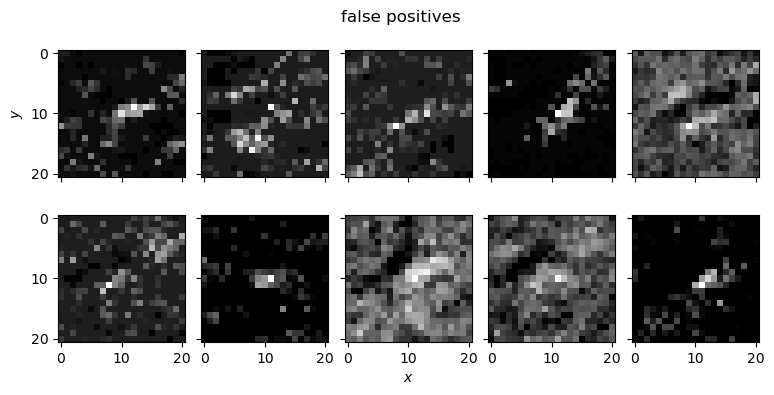

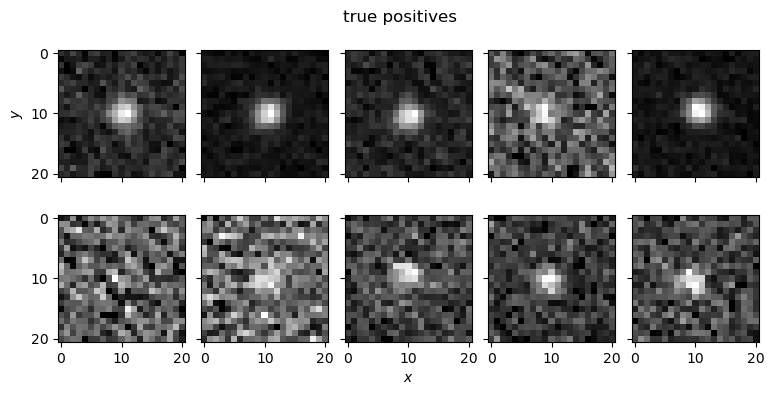

In [8]:
# plot sample of images
plot_image_array(no_point_source_stamps, title='false positives')
plot_image_array(point_source_stamps, title='true positives')

We don't actually have labels stored yet, since our labels come from which file each instance is associated with. The first thing we'll do is combine the instances from both files and make appropriate labels (0 for noise, 1 for a true point source).


In [9]:
# combine the false positives and true positives
input_stamps = np.vstack([no_point_source_stamps, point_source_stamps])
stamp_class = np.zeros(len(no_point_source_stamps) + len(point_source_stamps))
stamp_class[len(no_point_source_stamps) :] = 1  # 0 for noise, 1 for a star

We'll need one more helper function, to reshape the feature data and turn our labels into 1-hot encoded arrays. 

Pytorch has a $\texttt{one\_hot}$ method that makes this easy, we just need to get our numpy array into a tensor first. The way it works, the first column is used for the "noise" category encoding, and the second column is used for the "signal" category encoding. 

So [1, 0] will indicate that the category label for the instance was "0" (it was a noise instance) and [0, 1] will indicate that the category label was "1" (it was a true point source).

We could also have used sk-learn's one-hot encoder, but that one requires some extra lines of code, so I went with the pytorch version.

In [10]:
# code to reshape array into what keras expects
def reshape_arrays(data, labels):
    """reshape arrays for Keras"""
    data = data.reshape(-1, 21, 21, 1)
    labels = nn.functional.one_hot(torch.from_numpy(labels).long())
    return data, labels

We will use sk-learn's $\texttt{train\_test\_split}$ to split the data in to random selections with appropriate fractions of sources. We'll split twice to make training, validation, and test data sets.

In [11]:
# split the samples into training, validation and, test data sets:
train_frac = 0.7
val_frac = 0.1
test_frac = 0.2
# Note: we have to use train_test_split twice
data_train_val, data_test, class_train_val, class_test = train_test_split(
    input_stamps, stamp_class, test_size=test_frac, random_state=42
)
data_train, data_val, class_train, class_val = train_test_split(
    input_stamps, stamp_class, test_size=val_frac / (train_frac + val_frac), random_state=42
)

data_train, class_train = reshape_arrays(data_train, class_train)
data_val, class_val = reshape_arrays(data_val, class_val)
data_test, class_test = reshape_arrays(data_test, class_test)


In [12]:
print ('Number of samples in the training ({}); test ({}); and validation ({}) data sets'.format(data_train.shape[0], 
                                                                                    data_test.shape[0],
                                                                                   data_val.shape[0]))

Number of samples in the training (95832); test (21905); and validation (13691) data sets


For the sake of comparison, we'll study 2 models: a fully-connected neural network like the ones we tried last week, and a CNN model. 

### Version 1: Fully-Connected Neural Network

First, we'll try a fully-connected neural network using an input layer and a hidden layer. 

Along the way, I'll show you how to output labels for multiple categories (instead of probabilities of belonging to the positive category).

In [13]:
import keras

from keras import Input

from keras.models import Sequential #the model is built adding layers one after the other

from keras.layers import Dense #fully connected layers: every output talks to every input

from keras.layers import Flatten #for flattening tensor data

from keras.layers import Activation

In [14]:
model_fc = Sequential()

# Tell subsequent layers what shape to expect
model_fc.add(keras.Input(shape=(21, 21, 1)))

optimizer = keras.optimizers.AdamW(learning_rate=0.001)

# Add an input layer and specify its size (number of original features)

model_fc.add(Dense(30, activation='relu', input_shape=(21, 21, 1)))

# Add one hidden layer and specify its size

model_fc.add(Dense(30, activation='relu'))

# output layer 

model_fc.add(Flatten()) # because our inputs have been in the form of 2D tensors, we need to flatten them here

model_fc.add(Dense(2, activation='softmax')) #instead of outputting just 1 value (probability of positive category), we'll output 2 values that correspond to our 1-hot encoding scheme

model_fc.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy']) #we'll use cross-entropy loss to optimize, and monitor the accuracy

c:\Users\Ben\anaconda3\envs\PHYS448_Deep_Learning\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
print(model_fc.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 21, 21, 30)     │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 21, 21, 30)     │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 13230)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │        26,462 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,452 (107.23 KB)

 Trainable params: 27,452 (107.23 KB)

 Non-trainable params: 0 (0.00 B)

None


### Questions:
- How many hidden layers does the network have? 
- How many free parameters does the network have?

There is 1 hidden layer. 

There are 27,452 free parameters.

We begin with 20 epochs and batch size = 300. This took about 3 minutes on my laptop.

In [16]:
mynet = model_fc.fit(data_train, class_train, validation_data= (data_val, class_val), epochs=20, batch_size=300, shuffle=True)

Epoch 1/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.7566 - loss: 0.5185 - val_accuracy: 0.9068 - val_loss: 0.3060
Epoch 2/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.9154 - loss: 0.2389 - val_accuracy: 0.9284 - val_loss: 0.2063
Epoch 3/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - accuracy: 0.9285 - loss: 0.1843 - val_accuracy: 0.9113 - val_loss: 0.2269
Epoch 4/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.9334 - loss: 0.1647 - val_accuracy: 0.9284 - val_loss: 0.1801
Epoch 5/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.9377 - loss: 0.1523 - val_accuracy: 0.9373 - val_loss: 0.1586
Epoch 6/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.9405 - loss: 0.1438 - val_accuracy: 0.9424 - val_loss: 0.1438
Epoch 7/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.9444 - loss: 0.1352 - val_accuracy: 0.9459 - val_loss: 0.1368
Epoch 8/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.9478 - loss: 0.1276 - 

In [17]:
class_pred = model_fc.predict(data_test)

685/685 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


In [18]:
print(class_pred)

[[9.18e-04 9.99e-01]
 [6.87e-06 1.00e+00]
 [9.96e-01 4.42e-03]
 ...
 [1.00e+00 6.66e-10]
 [2.25e-01 7.75e-01]
 [9.91e-01 8.53e-03]]


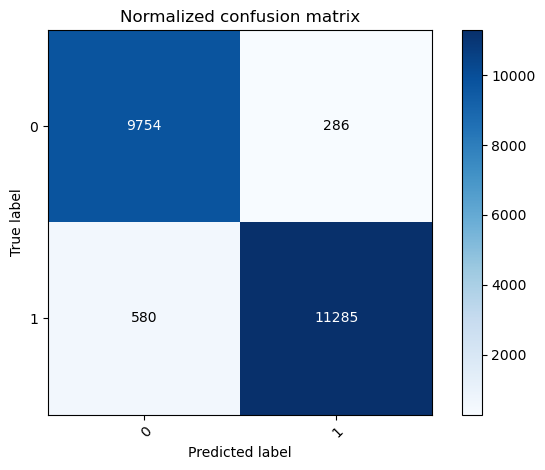

In [30]:
# plot the confusion matrix
# Feel free to turn normalization off to see the number of instances in each category instead
plot_confusion_matrix(np.argmax(class_test,axis=1), np.argmax(class_pred,axis=1), normalize=False,
                      title='Normalized confusion matrix')

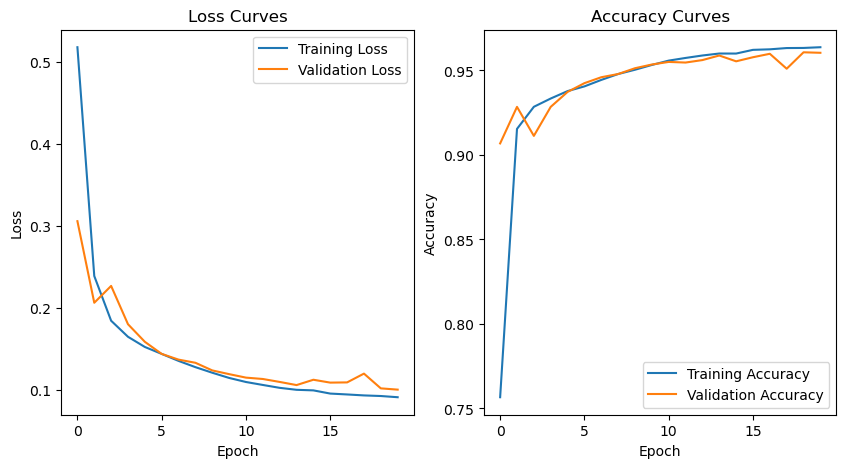

In [21]:
# plot the training history of the network
plot_model_history(mynet, 20)

In [43]:
tp = 9754
tn = 11285
fp = 286
fn = 580


test_acc = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)

print('Test Accuracy: %.2f%%' % (test_acc*100))
print('Precision: %.2f%%' % (precision*100))
print('Recall: %.2f%%' % (recall*100))

Test Accuracy: 96.05%
Precision: 97.15%
Recall: 94.39%


### Questions about the fully-connected network:
- Does the network appear to have converged in the number of epochs we used? Should we use more training epochs?
- Does this network have a problem with high variance? High bias?
- Give the test accuracy of the fully connected network (you'll probably need to do a little math using the confusion matrix above!).
- Are the recall and precision of the network balanced, or is the network giving more of one type of error (false positive vs. false negative)?

It looks like the network is starting to converge, but hasn't fully converged yet. More epochs should be used.

Overall the varience is pretty low, and the bias is pretty good too.

The test accuracy is 96.05%.

The precision is a little lower than the recall in this case. There are about twicw as many type II erroors than type I.

### Version 2: CNN

Now let's try a relatively simple CNN!

We'll try a model with 3 convolution layers and 2 max pooling layers.
At the end, we still want a fully connected layer to connect information from different parts of the image, plus our fully connected output layer that actually performs the classification.

In [22]:
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Dropout
from keras.layers import BatchNormalization

In [23]:
optimizer = keras.optimizers.AdamW(learning_rate=0.001)

model = Sequential()
# input: 21x21 images with 1 channel -> (21, 21, 1) tensors.
# this applies 16 convolution filters of size 3x3 each.
model.add(Conv2D(16, (3, 3), activation='relu', input_shape=(21, 21, 1), name='conv1'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(16, (3, 3), activation='relu', name='conv2'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(16, (3, 3), activation='relu', name='conv3'))

model.add(Flatten())

model.add(Dense(256, activation='relu', name='fc_1'))
# output layer

model.add(Dense(2, activation='softmax', name='fc_out'))

model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy']) #we'll use cross-entropy loss to optimize, and monitor the accuracy

c:\Users\Ben\anaconda3\envs\PHYS448_Deep_Learning\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 19, 19, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 9, 9, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 1, 1, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1 (Dense)                    │ (None, 256)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_out (Dense)                  │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,666 (37.76 KB)

 Trainable params: 9,666 (37.76 KB)

 Non-trainable params: 0 (0.00 B)

### Questions:
- How many hidden layers does the network have? Layers that don't add weights, like drop-out or pooling layers, are not considered hidden layers: they're "packaged" with the hidden layer they modify.
- How many free parameters does the network have?
- How do the number of free parameters in this model compare to the number in the fully connected neural network above?

There are 3 hidden layers.

There are 9,666 free parameters.

There are quite a bit less parameters in this model compared to the fully connected network. (About 3 times less)

Now we'll train the model, using 20 epochs again. To speed things up a bit, I'll use a batch size of 1000. 
This took about 2 minutes on my laptop.

In [25]:
mycnn = model.fit(data_train, class_train, validation_data= (data_val, class_val), epochs=20, batch_size=1000, shuffle=True)

Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.6547 - loss: 0.6041 - val_accuracy: 0.8696 - val_loss: 0.3805
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.8760 - loss: 0.2950 - val_accuracy: 0.9018 - val_loss: 0.2380
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.9074 - loss: 0.2149 - val_accuracy: 0.9134 - val_loss: 0.1937
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9201 - loss: 0.1819 - val_accuracy: 0.9287 - val_loss: 0.1618
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.9302 - loss: 0.1578 - val_accuracy: 0.9347 - val_loss: 0.1566
Epoch 6/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.9407 - loss: 0.1394 - val_accuracy: 0.9429 - val_loss: 0.1422
Epoch 7/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9615 - loss: 0.1002 - val_accuracy: 0.9604 - val_loss: 0.0988
Epoch 8/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.9709 - loss: 0.0783 - val_accuracy: 0.9748 - v

In [26]:
class_pred_cnn = model.predict(data_test)

685/685 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step


In [27]:
print(class_pred_cnn)

[[6.86e-05 1.00e+00]
 [1.62e-04 1.00e+00]
 [1.00e+00 3.19e-04]
 ...
 [1.00e+00 1.18e-07]
 [8.70e-01 1.30e-01]
 [8.81e-01 1.19e-01]]


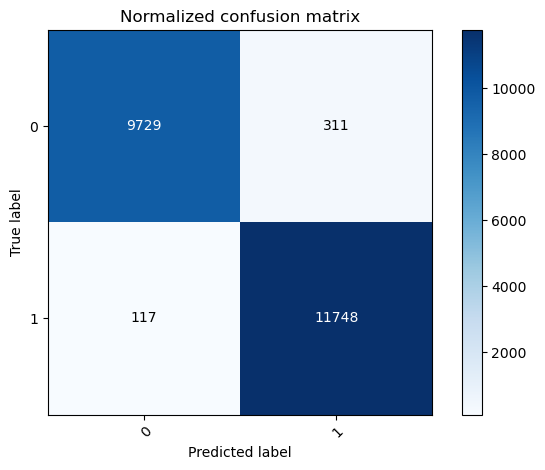

In [44]:
# plot the confusion matrix
plot_confusion_matrix(np.argmax(class_test,axis=1), np.argmax(class_pred_cnn,axis=1), normalize=False,
                      title='Normalized confusion matrix')

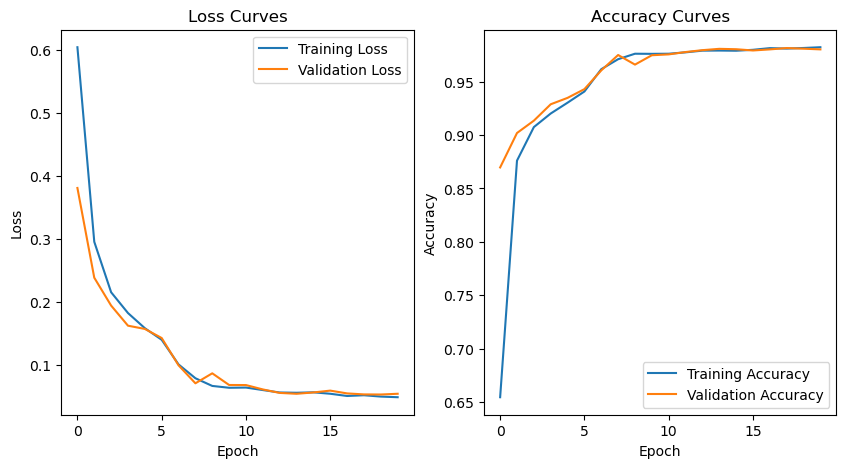

In [29]:
# plot the training history of the network
plot_model_history(mycnn, 20)

In [45]:
tp = 9729
tn = 11748
fp = 311
fn = 117


test_acc = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)

print('Test Accuracy: %.2f%%' % (test_acc*100))
print('Precision: %.2f%%' % (precision*100))
print('Recall: %.2f%%' % (recall*100))

Test Accuracy: 98.05%
Precision: 96.90%
Recall: 98.81%


### Questions about the CNN:
- Does the network appear to have converged in the number of epochs we used? Should we use more training epochs?
- Does this network have a problem with high variance? High bias?
- Give the test accuracy of the CNN (you'll probably need to do a little math using the confusion matrix above!).
- Are the recall and precision of the network balanced, or is the network giving more of one type of error (false positive vs. false negative)?

This time the network does seem to have converged.

Both the varience and bias are pretty low.

The test accuracy is 98.05%.

This time the precision and recall are pretty balanced. There are a bit more type I errors this time, but Peter's were pretty balenced overall.

### Question:
- Which seems to perform better, the fully connected neural network, or the convolutional neural network?

The CNN seems to be performing a little better.

### Understanding Neural Network Results


An interesting question to ask might be: what types of events is our network having trouble with? And are they the same ones the fully connected network had trouble with? Let's look at the images.

One issue we need to work with is that the predicted labels don't have values 0 or 1, they have decimal labels. We need to round the predicted labels first.  

In [33]:
class_pred_fc_rounded = np.round(class_pred)
class_pred_cnn_rounded = np.round(class_pred_cnn)

In [34]:
# Select images where the CNN labels don't match the true labels
# This isn't a very numpy-y way to do this, but it's easy to understand what's happening
test_mismatch_cnn = []
test_mismatch_cnn_true_labels = []
test_mismatch_cnn_pred_labels = []

for i in range(data_test.shape[0]):
    if np.all(class_pred_cnn_rounded[i] != class_test[i].numpy()):
        test_mismatch_cnn.append(data_test[i])
        test_mismatch_cnn_true_labels.append(class_test[i].numpy())
        test_mismatch_cnn_pred_labels.append(class_pred_cnn[i])

test_mismatch_cnn = np.array(test_mismatch_cnn)
test_mismatch_cnn_true_labels = np.array(test_mismatch_cnn_true_labels)
test_mismatch_cnn_pred_labels = np.array(test_mismatch_cnn_pred_labels)

In [35]:
# Same for the fully connected network

test_mismatch_fc = []
test_mismatch_fc_true_labels = []
test_mismatch_fc_pred_labels = []
for i in range(data_test.shape[0]):
    if np.all(class_pred_fc_rounded[i] != class_test[i].numpy()):
        test_mismatch_fc.append(data_test[i])
        test_mismatch_fc_true_labels.append(class_test[i].numpy())
        test_mismatch_fc_pred_labels.append(class_pred[i])

test_mismatch_fc = np.array(test_mismatch_fc)
test_mismatch_fc_true_labels = np.array(test_mismatch_fc_true_labels)
test_mismatch_fc_pred_labels = np.array(test_mismatch_fc_pred_labels)

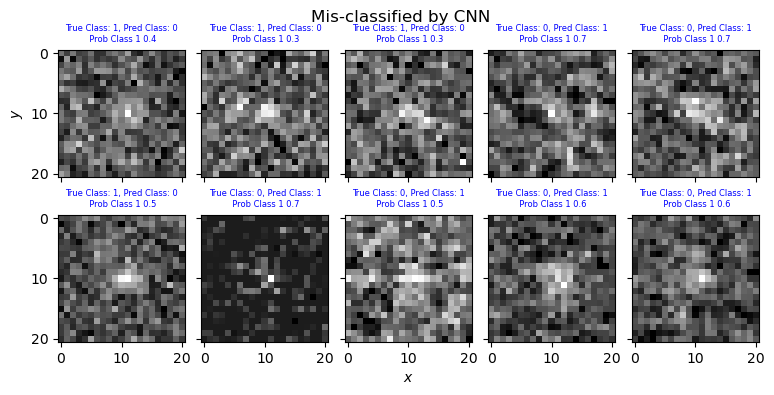

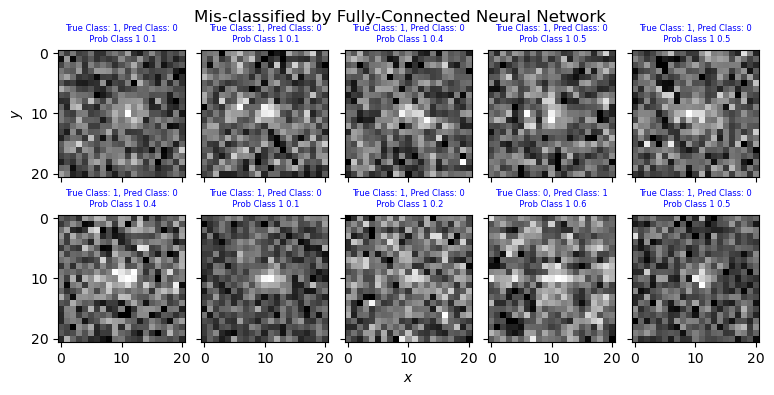

In [36]:
plot_image_array(test_mismatch_cnn, title='Mis-classified by CNN', subtitle=True, class_true=test_mismatch_cnn_true_labels, classes=test_mismatch_cnn_pred_labels)
plot_image_array(test_mismatch_fc, title = 'Mis-classified by Fully-Connected Neural Network', subtitle=True, class_true=test_mismatch_fc_true_labels, classes=test_mismatch_fc_pred_labels)

### Question:
What do you observe about the classification probabilities associated with mis-classified images, in most cases? Is the network confident about these classifications?

It seems that the propabilities are all over the place, which implies that the network is not very confident about these data points being correct. This is good, as we want to try to avoid the inverse.

How confident are these networks in general? We can check by making a histogram of the predictions.

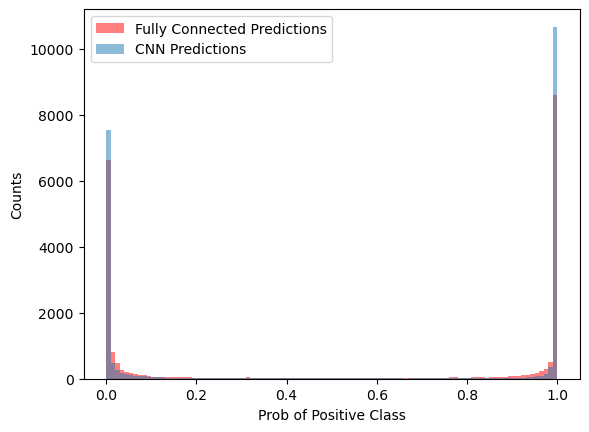

In [47]:
plt.hist(class_pred[:, 1], bins = 100, color='red', alpha = 0.5, label = "Fully Connected Predictions")
plt.hist(class_pred_cnn[:, 1], bins = 100, alpha = 0.5, label = "CNN Predictions")
plt.xlabel("Prob of Positive Class")
plt.ylabel("Counts")
plt.legend()
#plt.yscale('log')

### Question:
Which network is producing more ambiguous predictions (i.e. more predictions in the middling probability range)?

The fully connected network seems to have more ambiguous predictions implying that it is less confident overall.

From the predictions, it seems like our networks are pretty certain about most of the classifications! An interesting question to ask is whether the networks are every certain and incorrect, or if most of the mis-classifications are happening when the network is uncertain. The first one of these is far more dangerous!

Let's set a tighter threshold for classification and see what happens in the CNN. I'll use just the most confident ones: a 0.01 threshold for the negative class, and the 0.99 threshold for the positive class. Feel free to adjust these thresholds and see how things change. 

In [38]:
all_true = data_test[class_pred_cnn[:, 1]> 0.5] 
confident_true = data_test[class_pred_cnn[:, 1]> 0.99]

print(f"The CNN is confident about {confident_true.shape[0]/all_true.shape[0]:.3f} of class 1 predictions.")

all_false = data_test[class_pred_cnn[:, 1]< 0.5] 
confident_false = data_test[class_pred_cnn[:, 1]< 0.01]

print(f"The CNN is confident about {confident_false.shape[0]/all_false.shape[0]:.3f} of class 0 predictions.")

The CNN is confident about 0.885 of class 1 predictions.
The CNN is confident about 0.767 of class 0 predictions.


We'll try making a confusion matrix just for the confidently classified instances.

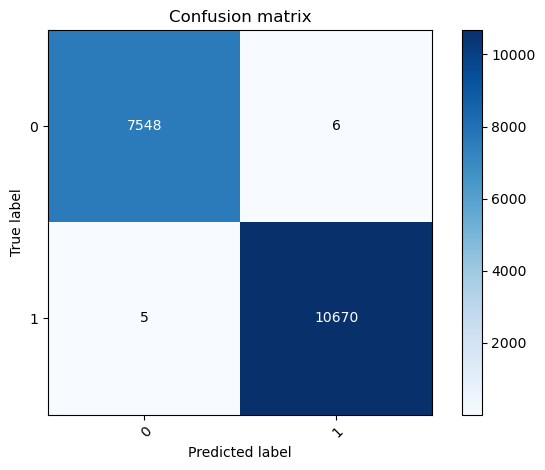

In [39]:
y_true_confident = class_test[(class_pred_cnn[:, 1]< 0.01) | (class_pred_cnn[:, 1]> 0.99)]
y_pred_confident = class_pred_cnn[(class_pred_cnn[:, 1]< 0.01) | (class_pred_cnn[:, 1]> 0.99)]

plot_confusion_matrix(np.argmax(y_true_confident,axis=1), np.argmax(y_pred_confident,axis=1), normalize=False,
                      title='Confusion matrix')


Better! Our false positive rate at this high threshold, in particular, is extremely low. 

### Interpreting Networks
Occulsion maps, saliency maps, class activation maps are all techniques for expressing which pixels contribute to classification. These are attempts to reduce the “black box” nature of the networks. 

The simplest of these is the occlussion map where we part of an image and calculate the probability of it belonging to a class. If the probability decreases the occluded part of the image is assumed to be important. If there is no change in probability the occluded pixels are not assumed to be important. A simple implementation of this is shown here.

In [40]:
def occlusiontest(model, image_number, kernel_size=5):
    input_stamp = data_test[image_number].reshape(21,21)
    i = 0
    j=0
    heatmap = []
    keras_stamps = []
    for j in range(22-kernel_size): # slide the occlusion kernel over the image
        for i in range(22-kernel_size):
            img = np.copy(input_stamp)
            img[i:i+kernel_size,j:j+kernel_size] = 0 # Turn off a section of the image
            img = normalize_image(img)
            keras_stamps.append(img) # add the occluded image to a list 
    keras_stamps = np.array(keras_stamps).reshape([-1,21,21,1])
    probs = 1. - model.predict(keras_stamps)  # predict for every occluded image
    heatmap = probs[:,1].reshape(22-kernel_size,22-kernel_size) # make a heatmap of the probability of correct point source ID given each occluded version
    # pad heatmap to same size as original image
    heatmap = np.pad(heatmap, pad_width=int(kernel_size/2), mode='minimum')
    return heatmap 

def transparent_cmap(cmap, N=255):
    "Copy colormap and set alpha values"
    mycmap = cmap
    mycmap._init()
    mycmap._lut[:,-1] = np.linspace(0, 0.8, N+4)
    return mycmap

def plot_occlusion_array(image_arr, heatmap_arr, nrows=2, ncols=5, figsize=[8,4], nx=21, ny=21, title='', subtitle=False, 
                     class_true=None, classes=None):


    '''Plot an array of images'''
    fig, ax = plt.subplots(nrows=nrows,ncols=ncols,figsize=figsize)
    fig.subplots_adjust(hspace=.3, left=0.07, right=0.95, wspace=0.1, bottom=0.15)
    for indx in np.arange(nrows*ncols):
        i = int(indx/ncols)
        j = indx%ncols
        if (i == 0):
            ax[i][j].xaxis.set_major_formatter(plt.NullFormatter())
        if (j != 0):
            ax[i][j].yaxis.set_major_formatter(plt.NullFormatter())

        ax[i][j].imshow(image_arr[indx].reshape(nx,ny), cmap='gray')
        ax[i][j].imshow(np.array(heatmap_arr[indx]), alpha=0.5, cmap=mycmap)
        if (subtitle == True):
            ax[i][j].set_title('True Class: %d, Pred Class: %d\n  Prob Class 1 %.1f ' % 
              (np.argmax(class_true[indx]), np.argmax(classes[indx]), classes[indx,1]), color='blue', fontsize=6)

    fig.suptitle(title)
    ax[0][0].set_ylabel('$y$')
    ax[nrows-1][int(ncols/2)].set_xlabel('$x$')           



Using this code, we can check the importance of each region of an image in making the classification:

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


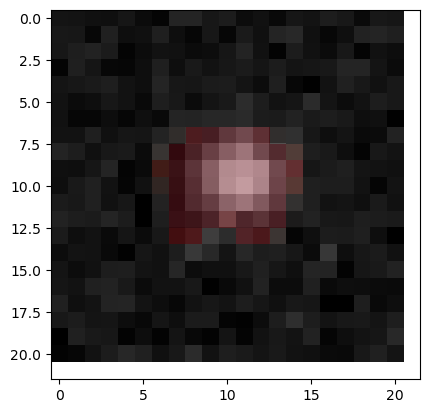

In [41]:
# use make a red transparent overlay
mycmap = transparent_cmap(plt.cm.Reds)

image_number = 1
kernel_size = 6
heatmap = occlusiontest(model, image_number, kernel_size)

fig, ax = plt.subplots(nrows=1,ncols=1)
ax.imshow(data_test[image_number].reshape(21,21), cmap='gray')
ax.imshow(np.array(heatmap), alpha=0.5, cmap=mycmap)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


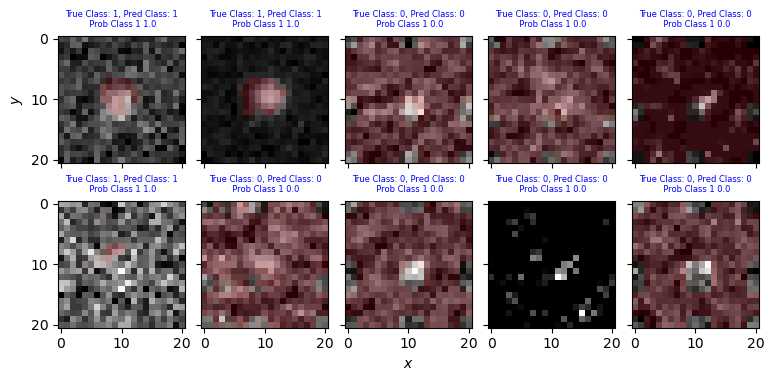

In [42]:
image_numbers = np.arange(10) #just looking at the first 10 images here, but you could choose to look at the confidently mis-classified images, for example!
heatmap_arr = []
image_arr = []
for indx in image_numbers:
    heatmap_arr.append(occlusiontest(model, indx))
    image_arr.append(data_test[indx])

heatmap_arr = np.array(heatmap_arr)
image_arr = np.array(image_arr)

plot_occlusion_array(image_arr, heatmap_arr, subtitle=True, class_true=class_test, classes=class_pred_cnn)


### Questions:
- Is the network looking in the same place for all images? 
- Which parts of the image are most important for images with point sources present? What about for noisy images?
- Does the information from the occlusion tests match your expectation?

No, however there is a petter for where it looks. When it is classified as 0, the network is looking at roughly the whole image. WHen it is classified as 1, the network is looking mostly at the center.

The center is most important for point source images, and there doesn't seem to be a specific point if interest for noisy images.

Yes because if it a positive class we should expect a point source in the center.

### Acknowledgement Statement:

That's it for today! Go ahead and submit to Gradescope. 